In [338]:
import os
import glob
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# imputation
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import cross_val_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error, r2_score

pd.set_option("display.max_columns", 100)

In [339]:
file_list = glob.glob(r"C:\Users\zahir\CRMLSSold*.csv")
dataframes = [pd.read_csv(file) for file in file_list]
df = pd.concat(dataframes, ignore_index=True)

C:\Users\zahir\AppData\Local\Temp\ipykernel_18324\405482455.py:2: DtypeWarning: Columns (78,79) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes = [pd.read_csv(file) for file in file_list]
C:\Users\zahir\AppData\Local\Temp\ipykernel_18324\405482455.py:2: DtypeWarning: Columns (2,36,39,56,74) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes = [pd.read_csv(file) for file in file_list]
C:\Users\zahir\AppData\Local\Temp\ipykernel_18324\405482455.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes = [pd.read_csv(file) for file in file_list]
C:\Users\zahir\AppData\Local\Temp\ipykernel_18324\405482455.py:2: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes = [pd.read_csv(file) for file in file_list]


In [340]:
df = df[(df["PropertyType"] == "Residential") & (df["PropertySubType"] == "SingleFamilyResidence")]

---
# 1. Initial Data Cleaning

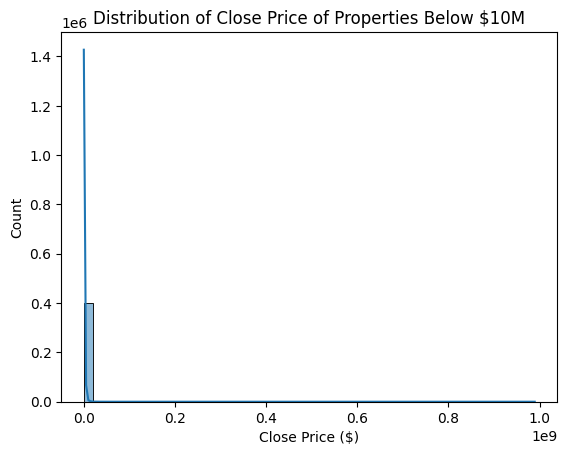

In [341]:
sns.histplot(df['ClosePrice'], kde=True, bins=50)
plt.title('Distribution of Close Price of Properties Below $10M')
plt.xlabel('Close Price ($)');

In [342]:
initial_length = len(df)
# There should not be any zero values in the ClosePrice column, and the extremely high values are outliers

print(f"Minimum Close Price: ${df['ClosePrice'].min():,.2f}")
print(f"Maximum Close Price: ${df['ClosePrice'].max():,.2f}")

# Remove 1st and 99th percentile outliers in ClosePrice
lower_quantile = df["ClosePrice"].quantile(0.01)
upper_quantile = df["ClosePrice"].quantile(0.99)
df = df[df["ClosePrice"].between(lower_quantile, upper_quantile)]

Minimum Close Price: $0.00
Maximum Close Price: $989,500,000.00


In [343]:
# Remove duplicate observations
df = df.drop_duplicates(subset=['ListingKey', 'ClosePrice', 'CloseDate'], keep='first')
print(f"Dropped {initial_length - len(df)} observations, {len(df)} remain")

Dropped 7921 observations, 391236 remain


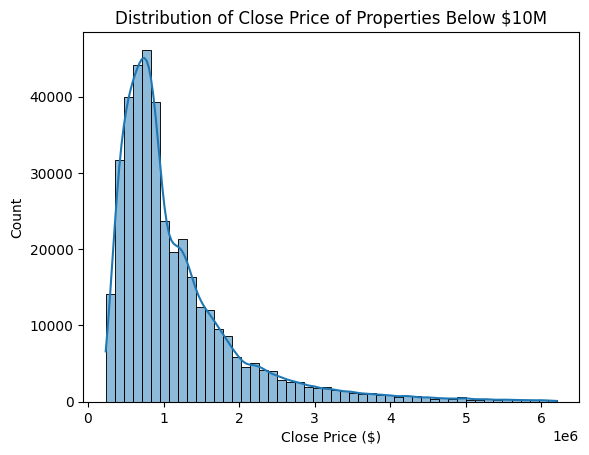

In [344]:
sns.histplot(df['ClosePrice'], kde=True, bins=50)
plt.title('Distribution of Close Price of Properties Below $10M')
plt.xlabel('Close Price ($)');

In [345]:
# Keep Postal Code to first 5 digits and convert to floats
clean_postal = df["PostalCode"].astype(str).str.strip().str.lower()
sliced_postal = clean_postal.str.slice(0, 5)
numeric_postal = pd.to_numeric(sliced_postal, errors='coerce')
df["PostalCode"] = numeric_postal.astype("float64")
df = df.dropna(subset=["PostalCode"])

In [346]:
# Constrain observations to those only with CA postal codes (90000-96162)
before_postal_filter = len(df)
df = df[(df["PostalCode"] >= 90000) & (df["PostalCode"] <= 96162)]
print(f"Dropped {before_postal_filter - len(df)} observations outside CA postal code range, {len(df)} remain")

Dropped 51 observations outside CA postal code range, 391183 remain


---
# 2. Missing Data Handling

In [347]:
# initial shape
print(f"Initial shape: {df.shape}")

Initial shape: (391183, 82)


In [348]:
missing_percentages = df.isna().sum()[df.isna().sum() > 0] / len(df)
missing_percentages = pd.DataFrame(missing_percentages, columns=["MissingPercentage"]).sort_values(by="MissingPercentage", ascending=False)
missing_percentages.head(15)

,MissingPercentage
TaxAnnualAmount,1.000000
AboveGradeFinishedArea,1.000000
ElementarySchoolDistrict,1.000000
BusinessType,1.000000
FireplacesTotal,1.000000
MiddleOrJuniorSchoolDistrict,1.000000
CoveredSpaces,1.000000
TaxYear,1.000000
WaterfrontYN,0.999611
BelowGradeFinishedArea,0.994235


In [349]:
ZERO_INFO_COLS = [
    "TaxAnnualAmount", "AboveGradeFinishedArea", "TaxYear",
    "ElementarySchoolDistrict", "CoveredSpaces", "BusinessType",
    "MiddleOrJuniorSchoolDistrict", "FireplacesTotal", "PropertySubType"
]

ID_COLS = [
    "ListingKeyNumeric", "ListingId", "ListingKey"
    "UnparsedAddress", "StreetNumberNumeric",
]

AGENT_OFFICE_COLS = [
    "ListAgentFirstName", "ListAgentLastName", "ListAgentFullName",
    "ListAgentEmail", "ListAgentAOR","BuyerAgentFirstName", "BuyerAgentLastName", 
    "BuyerAgentMlsId", "BuyerAgentAOR", "CoListAgentFirstName", "CoListAgentLastName", 
    "CoBuyerAgentFirstName", "ListOfficeName", "BuyerOfficeName", "CoListOfficeName", 
    "BuyerOfficeAOR", "BuyerAgencyCompensation", "BuyerAgencyCompensationType",
]

DATA_LEAKAGE_COLS = ["ListPrice", "OriginalListPrice", "DaysOnMarket", "PurchaseContractDate"]

TARGET = "ClosePrice"

DROP_NOW = (ZERO_INFO_COLS + ID_COLS + AGENT_OFFICE_COLS
            + DATA_LEAKAGE_COLS)

before_cols = df.shape[1]
df = df.drop(columns=[c for c in DROP_NOW if c in df.columns])
print(f"Dropped {before_cols - df.shape[1]} columns, {df.shape[1]} remain")

Dropped 34 columns, 48 remain


In [350]:
YN_COLS = ["ViewYN", "WaterfrontYN", "BasementYN", "PoolPrivateYN",
           "AttachedGarageYN", "NewConstructionYN", "FireplaceYN"]

for c in YN_COLS:
    print(df.groupby(df[c].astype("object"), dropna=False)[TARGET].agg(["mean", "count"]))

                mean   count
ViewYN                      
False   1.113622e+06  141117
True    1.200205e+06  210699
NaN     1.173135e+06   39367
                      mean   count
WaterfrontYN                      
NaN           1.165921e+06  391031
True          2.003643e+06     152
                    mean   count
BasementYN                      
NaN         1.158160e+06  382024
True        1.503546e+06    9159
                       mean   count
PoolPrivateYN                      
False          1.021555e+06  295920
True           1.402482e+06   56206
NaN            1.922558e+06   39057
                          mean   count
AttachedGarageYN                      
False             1.145600e+06   57975
True              1.167680e+06  289809
NaN               1.184253e+06   43399
                           mean   count
NewConstructionYN                      
NaN                1.227614e+06   39190
False              1.166416e+06  338536
True               9.832611e+05   13457
        

In [351]:
df = df.dropna(subset=['PoolPrivateYN', 'AttachedGarageYN', 'NewConstructionYN', 'FireplaceYN', 'ViewYN'])
df[['WaterfrontYN', 'BasementYN']] = df[['WaterfrontYN', 'BasementYN']].fillna(False)

# Boolean Encoding for YN columns
for c in YN_COLS:
    df[c] = df[c].map({True: 1, False: 0}).fillna(0).astype(int)

C:\Users\zahir\AppData\Local\Temp\ipykernel_18324\1492957697.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[['WaterfrontYN', 'BasementYN']] = df[['WaterfrontYN', 'BasementYN']].fillna(False)


In [352]:
# Reprint Missing Percentages after dropping columns and filling values
missing_percentages = df.isna().sum()[df.isna().sum() > 0] / len(df)
missing_percentages = pd.DataFrame(missing_percentages, columns=["MissingPercentage"]).sort_values(by="MissingPercentage", ascending=False)
missing_percentages.head(10)

,MissingPercentage
BelowGradeFinishedArea,0.992177
BuildingAreaTotal,0.963935
LotSizeDimensions,0.952567
BuilderName,0.940608
ElementarySchool,0.839799
MiddleOrJuniorSchool,0.835053
HighSchool,0.782340
AssociationFeeFrequency,0.709150
SubdivisionName,0.674925
latfilled,0.595788


In [353]:
DROP_SPARSE_COLS = [
    "BelowGradeFinishedArea", "BuilderName", "LotSizeDimensions",
    "BuildingAreaTotal", "ElementarySchool", "MiddleOrJuniorSchool",
    "HighSchool", "Flooring",
]
before_cols = df.shape[1]
df = df.drop(columns=[c for c in DROP_SPARSE_COLS if c in df.columns])
print(f"Dropped {before_cols - df.shape[1]} sparse/low-value columns -> {df.shape[1]} remain")

df["HasNamedSubdivision"] = df["SubdivisionName"].notna().astype(int) #Convert Subdivision Name to a binary feature (1 = Has, 0 = Does not have)
df = df.drop(columns=["SubdivisionName"])

print("\nRemaining columns with any missingness:")
missing_percentages = df.isna().sum()[df.isna().sum() > 0] / len(df)
missing_percentages = pd.DataFrame(missing_percentages, columns=["MissingPercentage"]).sort_values(by="MissingPercentage", ascending=False)
missing_percentages.head(10)

Dropped 8 sparse/low-value columns -> 40 remain

Remaining columns with any missingness:


,MissingPercentage
AssociationFeeFrequency,0.709150
lonfilled,0.595788
latfilled,0.595788
MainLevelBedrooms,0.170918
HighSchoolDistrict,0.138710
AssociationFee,0.111895
MLSAreaMajor,0.065213
Stories,0.048307
Levels,0.020840
GarageSpaces,0.016470


In [354]:
DIAG_PREDICTORS = ["Latitude", "Longitude", "LivingArea", "YearBuilt",
                    "BedroomsTotal", "BathroomsTotalInteger"]
_diag_X = df[DIAG_PREDICTORS].fillna(df[DIAG_PREDICTORS].median(numeric_only=True))


def missingness_report(frame, col, cat_group_cols=("CountyOrParish", "MLSAreaMajor")):
    print(f"\n{'='*60}\nMissingness diagnostic: {col}\n{'='*60}")
    is_missing = frame[col].isna()
    print(f"Overall missing rate: {is_missing.mean():.1%}  (n={int(is_missing.sum())} / {len(frame)})")

    close_month = pd.to_datetime(frame["CloseDate"], errors="coerce").dt.to_period("M")
    by_month = is_missing.groupby(close_month).mean().sort_index()
    print("\nMissing rate by month (first 3 / last 3):")
    print(pd.concat([by_month.head(3), by_month.tail(3)]))

    for gcol in cat_group_cols:
        if gcol in frame.columns and gcol != col:
            rate_by_group = is_missing.groupby(frame[gcol]).mean().sort_values(ascending=False)
            print(f"\nMissing rate by {gcol} (top 5):")
            print(rate_by_group.head(5))

    y = is_missing.astype(int)
    if y.nunique() == 2 and y.sum() >= 20 and (len(y) - y.sum()) >= 20:
        clf = LogisticRegression(max_iter=500)
        try:
            aucs = cross_val_score(clf, _diag_X, y, cv=3, scoring="roc_auc")
            print(f"\nAUC predicting '{col} is missing': {aucs.mean():.3f}"
                  "  (near 0.5 -> MCAR/MAR-like; higher -> structured, keep a *_missing flag)")
        except ValueError as e:
            print(f"\n(skipped predictability check: {e})")

    print(f"\n{TARGET} by missingness status:")
    print(frame.groupby(is_missing)[TARGET].agg(["mean", "median", "count"]))


for col in ["MainLevelBedrooms", "HighSchoolDistrict", "MLSAreaMajor",
            "Stories", "AssociationFeeFrequency"]:
    missingness_report(df, col)



Missingness diagnostic: MainLevelBedrooms
Overall missing rate: 17.1%  (n=42278 / 247358)

Missing rate by month (first 3 / last 3):
CloseDate
2022-01    0.085735
2022-02    0.065806
2022-03    0.116279
2026-03    0.197874
2026-04    0.202520
2026-05    0.189583
Freq: M, Name: MainLevelBedrooms, dtype: float64

Missing rate by CountyOrParish (top 5):
CountyOrParish
Other           1.000000
Contra Costa    0.978863
Alameda         0.969591
Santa Cruz      0.930636
San Mateo       0.919315
Name: MainLevelBedrooms, dtype: float64

Missing rate by MLSAreaMajor (top 5):
MLSAreaMajor
DC540 - Yucca Valley Northwest       1.0
DC530 - Yucca Valley Southeast       1.0
DC520 - Yucca Valley Southwest       1.0
DC510 - Morongo Valley               1.0
660 - La Tuna Canyon and Adjacent    1.0
Name: MainLevelBedrooms, dtype: float64

AUC predicting 'MainLevelBedrooms is missing': 0.616  (near 0.5 -> MCAR/MAR-like; higher -> structured, keep a *_missing flag)

ClosePrice by missingness status:
      

#### Missingness Report of Most Null Features - Summary:

All five AUCs are well above 0.5 (0.61–0.97), not missing completely at random. Missingness on these fields is highly predictable from other property characteristics, meaning there are structural reasons for the 40% overall missingness.

The county/area breakdowns show why: entire counties are sitting at ~100% missing for a given field:
- MainLevelBedrooms and HighSchoolDistrict are both 100% missing for San Diego
- Stories is 93–97% missing across Santa Cruz, San Benito, Monterey, San Mateo, Santa Clara — the Bay Area/Central Coast
- AssociationFeeFrequency is 100% missing in Alpine, Colusa, Humboldt, Lassen, Trinity

This is likely a per-MLS-board reporting gap, not a property-level phenomenon. CRMLS aggregates feeds from multiple regional MLS organizations, and they don't all populate the same fields. That also explains the large ClosePrice gaps (Stories missing group averages $2.06M vs. $1.16M present; MainLevelBedrooms missing group $1.62M vs $1.05M). That's almost certainly a regional confound, as the Bay Area and coastal counties driving the missingness are just more expensive markets.


In [355]:
# Drop AssociationFee and AssociationFeeFrequency since they are mostly missing, difficult to impute given context, and signal accounted for in geographic features.
df = df.drop(columns=["AssociationFee", "AssociationFeeFrequency"])

# Highly Missing, and Stories and BedroomsTotal are more useful. Single story homes have all bedrooms on the first floor.
df = df.drop(columns=["MainLevelBedrooms"]) 


# Fill in Latitude and Longitude from latfilled/lonfilled if present, then drop the latter
for base, filled in [("Latitude", "latfilled"), ("Longitude", "lonfilled")]:
    if filled in df.columns:
        agree_check = df[[base, filled]].dropna()
        if len(agree_check):
            diff = (agree_check[base] - agree_check[filled]).abs()
            print(f"{base} vs {filled} on {len(agree_check)} rows where both populated: "
                  f"median abs diff = {diff.median():.5f}, max = {diff.max():.5f}")
        df[base] = df[base].fillna(df[filled])
        df = df.drop(columns=[filled])

# Fill in missing values for categorical columns with "Unknown" to avoid dropping rows with missing values in these columns.
for col in ["HighSchoolDistrict", "MLSAreaMajor", "Levels"]:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

print("Shape after Step C:", df.shape)

Latitude vs latfilled on 99968 rows where both populated: median abs diff = 33.91722, max = 564.00000
Longitude vs lonfilled on 99968 rows where both populated: median abs diff = 117.99558, max = 125.10279
Shape after Step C: (247358, 35)


---
# 3. Train / Test Splitting

##### KNN Imputation performed the best as expected.


In [358]:
df["CloseDate"] = pd.to_datetime(df["CloseDate"])
df["CloseMonth"] = df["CloseDate"].dt.to_period("M")
all_months = sorted(df["CloseMonth"].unique(), reverse=True)
TEST_MONTH = all_months[0]
TRAIN_MONTHS = all_months[1:13]  # Use the 12 months prior to the test month for training == our "X" for future testing of the optimal train length

train_df = df[df['CloseMonth'].isin(TRAIN_MONTHS)]
test_df = df[df['CloseMonth'] == TEST_MONTH]

In [359]:
print(f"Split -> train: {train_df.shape}, test: {test_df.shape}")
print(f"Train Percentage of data: {len(train_df) / (len(train_df) + len(test_df)):.2%}, Test Percentage of data: {len(test_df) / (len(train_df) + len(test_df)):.2%}")

Split -> train: (84148, 36), test: (7622, 36)
Train Percentage of data: 91.69%, Test Percentage of data: 8.31%


# 4. Imputation, Normalization, and Encoding 

In [356]:
# Convert lat and long into floats
df[['Latitude', 'Longitude']] = df[['Latitude', 'Longitude']].astype("float64")

In [357]:
df[["Latitude", "Longitude", "LivingArea", "YearBuilt","BedroomsTotal", "BathroomsTotalInteger"]].dtypes

Latitude                 float64
Longitude                float64
LivingArea               float64
YearBuilt                float64
BedroomsTotal            float64
BathroomsTotalInteger    float64
dtype: object

In [360]:
IMPUTE_PREDICTORS = ["Latitude", "Longitude", "LivingArea", "YearBuilt",
                      "BedroomsTotal", "BathroomsTotalInteger"]
RANDOM_STATE = 42

TIER_GROUP_COLS = [
    ["PostalCode"],
    ["CountyOrParish"],
]

def fit_tiered_group_median(train_frame, col):
    tiers = []
    for group_cols in TIER_GROUP_COLS:
        lookup = (train_frame.dropna(subset=[col]).groupby(group_cols)[col].median().rename("tier_med").reset_index())
        tiers.append((group_cols, lookup))
    statewide_fallback = train_frame[col].median()
    return tiers, statewide_fallback


def apply_tiered_group_median(frame, col, tiers, statewide_fallback):
    filled = frame[col].copy()
    for group_cols, lookup in tiers:
        still_missing = filled.isna()
        if not still_missing.any():
            break
        merged = frame.loc[still_missing].merge(lookup, on=group_cols, how="left")
        tier_values = pd.Series(merged["tier_med"].values, index=frame.index[still_missing])
        filled.loc[still_missing] = tier_values
    return filled.fillna(statewide_fallback)


known_idx = df.index[df["Stories"].notna()]
rng = np.random.default_rng(RANDOM_STATE)
holdout_idx = rng.choice(known_idx, size=int(0.2 * len(known_idx)), replace=False)

eval_df = df.copy()
eval_df.loc[holdout_idx, "Stories"] = np.nan  # pretend these are missing too
true_values = df.loc[holdout_idx, "Stories"]

def method_global_median(frame):
    return frame["Stories"].fillna(frame["Stories"].median())

def method_tiered_median(frame):
    tiers, fallback = fit_tiered_group_median(frame, "Stories")
    return apply_tiered_group_median(frame, "Stories", tiers, fallback)

def method_knn(frame, k=15):
    col = "Stories"
    known_mask = frame[col].notna()
    predictors = frame[IMPUTE_PREDICTORS].fillna(frame[IMPUTE_PREDICTORS].median(numeric_only=True))

    scaler = StandardScaler().fit(predictors.loc[known_mask])
    X_scaled = scaler.transform(predictors)

    filled = frame[col].copy()
    missing_mask = ~known_mask
    if not missing_mask.any():
        return filled


    nn = NearestNeighbors(n_neighbors=k, algorithm="ball_tree")
    nn.fit(X_scaled[known_mask.values])
    _, neighbor_idx = nn.kneighbors(X_scaled[missing_mask.values])

    known_values = frame.loc[known_mask, col].to_numpy()
    filled.loc[missing_mask] = np.median(known_values[neighbor_idx], axis=1)
    return filled

methods = {
    "global_median": method_global_median,
    "knn (k=15, geographic)": method_knn, 
    "tiered_median": method_tiered_median,
    # Originally tested Iterative Imputation, but is ideal when data is Missing at Random and was too computationally expensive here
}

comparison = []
for name, fn in methods.items():
    pred = fn(eval_df)
    mae = mean_absolute_error(true_values, pred.loc[holdout_idx])
    comparison.append({"method": name, "MAE": mae})

comparison_df = pd.DataFrame(comparison).sort_values("MAE").reset_index(drop=True)
comparison_df

,method,MAE
0,"knn (k=15, geographic)",0.118179
1,tiered_median,0.274145
2,global_median,0.360528


In [361]:
def fit_knn_imputer(train_frame, col, predictor_cols=IMPUTE_PREDICTORS, k=15):
    known_mask = train_frame[col].notna()
    predictor_medians = train_frame[predictor_cols].median(numeric_only=True)
    predictors = train_frame[predictor_cols].fillna(predictor_medians)
    scaler = StandardScaler().fit(predictors.loc[known_mask])
    nn = NearestNeighbors(n_neighbors=k, algorithm="ball_tree")
    nn.fit(scaler.transform(predictors.loc[known_mask]))
    known_values = train_frame.loc[known_mask, col].to_numpy()
    return {"nn": nn, "scaler": scaler, "known_values": known_values, "predictor_medians": predictor_medians, "predictor_cols": predictor_cols}

def apply_knn_imputer(frame, col, fitted):
    filled = frame[col].copy()
    missing_mask = filled.isna()
    if not missing_mask.any():
        return filled
    predictors = frame[fitted["predictor_cols"]].fillna(fitted["predictor_medians"])
    X_scaled = fitted["scaler"].transform(predictors.loc[missing_mask])
    _, neighbor_idx = fitted["nn"].kneighbors(X_scaled)
    filled.loc[missing_mask] = np.median(fitted["known_values"][neighbor_idx], axis=1)
    return filled

In [362]:
pd.options.mode.chained_assignment = None

NUMERIC_MISSING_COLS = [c for c in train_df.select_dtypes(include=[np.number]).columns if train_df[c].isna().any() and c != TARGET]
print("Columns to KNN-impute:", NUMERIC_MISSING_COLS)

for col in NUMERIC_MISSING_COLS:    # fit and train for both train and test sets
    fitted = fit_knn_imputer(train_df, col) 
    train_df[col] = apply_knn_imputer(train_df, col, fitted)
    test_df[col] = apply_knn_imputer(test_df, col, fitted)

print("Remaining NaNs -> train:", train_df.isna().sum().sum(), " test:", test_df.isna().sum().sum())

Columns to KNN-impute: ['LivingArea', 'ParkingTotal', 'LotSizeAcres', 'YearBuilt', 'BathroomsTotalInteger', 'Stories', 'LotSizeArea', 'GarageSpaces', 'LotSizeSquareFeet']
Remaining NaNs -> train: 54  test: 4


In [ ]:
train_df = train_df.dropna(subset=["City", "UnparsedAddress"])
test_df = test_df.dropna(subset=["City", "UnparsedAddress"])

In [365]:
print("Remaining NaNs -> train:", train_df.isna().sum().sum(), " test:", test_df.isna().sum().sum())

Remaining NaNs -> train: 0  test: 0


In [ ]:
EXCLUDE_FROM_SCALING = {TARGET, "CloseDate"}
BINARY_LIKE_COLS = {c for c in train_df.columns if train_df[c].dropna().isin([0, 1]).all() and train_df[c].nunique() <= 2}
scale_cols = [c for c in train_df.select_dtypes(include=[np.number]).columns if c not in EXCLUDE_FROM_SCALING and c not in BINARY_LIKE_COLS]

scaler = StandardScaler()
train_df[scale_cols] = scaler.fit_transform(train_df[scale_cols])
test_df[scale_cols] = scaler.transform(test_df[scale_cols])

In [368]:
print(f"train_df.shape: {train_df.shape}, test_df.shape: {test_df.shape}, df.shape: {df.shape}")

train_df.shape: (84094, 36), test_df.shape: (7618, 36), df.shape: (247358, 36)


In [369]:
# Export the preprocessed train and test datasets to CSV files for further analysis or modeling
train_df.to_csv("train_preprocessed.csv", index=False)
test_df.to_csv("test_preprocessed.csv", index=False)
df.to_csv("full_data_preprocessed.csv", index=False)